# TRAINING MODEL

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv("./datasets/skin_cancer.csv")

categorical_cols = [
    "HeartDisease",
    "Smoking",
    "AlcoholDrinking",
    "Stroke",
    "DiffWalking",
    "Sex",
    "AgeCategory",
    "Race",
    "Diabetic",
    "PhysicalActivity",
    "GenHealth",
    "Asthma",
    "KidneyDisease"
]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df[col])
    encoders[col] = le

df_true = df[df["SkinCancer"] == "Yes"]
df_false = df[df["SkinCancer"] == "No"]
df_len_data = 29800
df_true_sample = df_true.sample(n=df_len_data, random_state=42)
df_false_sample = df_false.sample(n=df_len_data, random_state=42)
df_subset = pd.concat([df_true_sample, df_false_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

for col in categorical_cols:
    df_subset[col] = encoders[col].transform(df_subset[col])

X_cols = df_subset.drop(columns=["SkinCancer"]).columns.tolist()
X = df_subset[X_cols].values
y = df_subset["SkinCancer"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Jumlah train:", len(X_train))
print("Jumlah test:", len(X_test))


Jumlah train: 47680
Jumlah test: 11920


In [8]:
class BayesianDecisionModel:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.prior = {}

        for c in self.classes:
            Xc = X[y == c]
            self.mean[c] = Xc.mean(axis=0)
            self.var[c] = Xc.var(axis=0) + 1e-6
            self.prior[c] = len(Xc) / len(X)

        self.build_loss_matrix()

    loss = {
        0: {0:0, 1:100},
        1: {0:10, 1:0}
    }
    
    def gaussian(self, c, x):
        mean, var = self.mean[c], self.var[c]
        return np.exp(-(x-mean)**2 / (2*var)) / np.sqrt(2*np.pi*var)

    def posterior(self, x):
        post = {}
        for c in self.classes:
            post[c] = np.prod(self.gaussian(c, x)) * self.prior[c]
        Z = sum(post.values())
        for c in post:
            post[c] /= Z
        return post

    def predict(self, X):
        return np.array([max(self.posterior(x), key=self.posterior(x).get) for x in X])

    def bayesian_update(self, prior, likelihood):
        unnorm = prior * likelihood
        return unnorm / np.sum(unnorm)

    def EMV(self, posterior):
        risks = []
        for d in self.classes:
            risks.append(sum(self.loss[d][c]*posterior[c] for c in self.classes))
        return min(risks)

    def EVSI(self, X):
        EMV0 = self.EMV(self.prior)
        return EMV0 - self.EVwSI(X)

    def EVwSI(self, X):
        return np.mean([self.EMV(self.posterior(x)) for x in X])

    def build_loss_matrix(self):
        c0, c1 = self.classes
        self.loss = {
            c0: {c0:0,  c1:150},
            c1: {c0:15, c1:0}
        }
    
    def clinical_decision(self, posterior):
        threshold = 0.20
        if posterior[self.classes[1]] >= threshold:
            return self.classes[1]
        return self.classes[0]

In [9]:
model = BayesianDecisionModel()
model.fit(X_train, y_train)

--- Hasil Evaluasi Teroptimasi ---
Accuracy    : 0.7098
EVSI        : 3.3310
Precision   : 0.6917
Recall      : 0.7571
F1 Score    : 0.7229


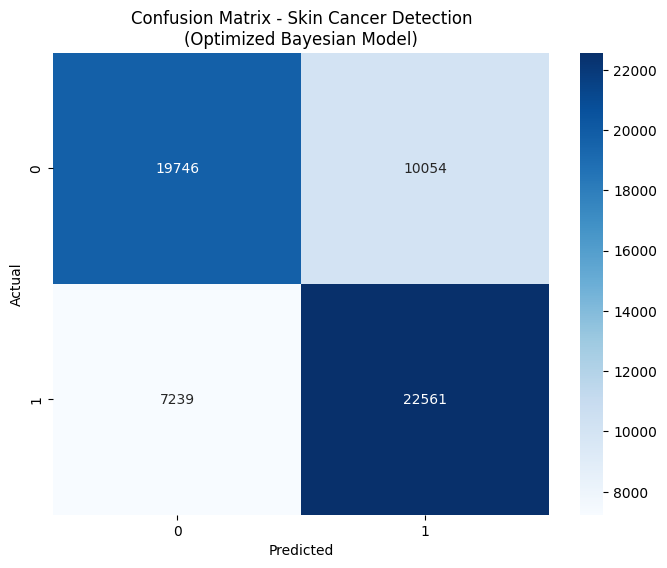

In [11]:
pred = model.predict(X)
evsi_res = model.EVSI(X)

label_map = {'No': 0, 'Yes': 1}
y_num = np.array([label_map[v] for v in y]) if y.dtype == object else y
pred_num = np.array([label_map[v] for v in pred]) if isinstance(pred[0], str) else pred
labels = [0, 1]

print(f"--- Hasil Evaluasi Teroptimasi ---")
print(f"Accuracy    : {accuracy_score(y_num, pred_num):.4f}")
print(f"EVSI        : {evsi_res:.4f}")
print(f"Precision   : {precision_score(y_num, pred_num):.4f}")
print(f"Recall      : {recall_score(y_num, pred_num):.4f}")
print(f"F1 Score    : {f1_score(y_num, pred_num):.4f}")

cm = confusion_matrix(y_num, pred_num)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Skin Cancer Detection\n(Optimized Bayesian Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# PREDIKSI

In [17]:
def predict_patient(patient):
    x = []
    for col in X_cols:
        val = patient[col]
        if col in encoders:
            if val not in encoders[col].classes_:
                raise ValueError(f"Value '{val}' tidak ada di kolom '{col}' saat training!")
            val = encoders[col].transform([val])[0]
        else:
            val = float(val)
        x.append(val)
    x = np.array(x)
    posterior = model.posterior(x)
    decision = model.clinical_decision(posterior)
    return decision, posterior

In [18]:
patient = {    
    "HeartDisease": "No",
    "BMI": 18.13,
    "Smoking": "No",
    "AlcoholDrinking": "No",
    "Stroke": "No",
    "PhysicalHealth": 0.0,
    "MentalHealth": 0.0,
    "DiffWalking": "No",
    "Sex": "Male",
    "AgeCategory": "80 or older",
    "Race": "White",
    "Diabetic": "No",
    "PhysicalActivity": "Yes",
    "GenHealth": "Excellent",
    "SleepTime": 8.0,
    "Asthma": "No",
    "KidneyDisease": "No"
}

decision, posterior = predict_patient(patient)

print("=== HASIL DIAGNOSIS ===")
print("Keputusan Sistem :", decision)
print("Posterior :", posterior)

=== HASIL DIAGNOSIS ===
Keputusan Sistem : Yes
Posterior : {'No': np.float64(0.36171519066874497), 'Yes': np.float64(0.6382848093312551)}


# SAVE MODEL

In [16]:
import os
import joblib

os.makedirs("model", exist_ok=True)

joblib.dump(model, "model/bdt_skin_model.pkl")
joblib.dump(encoders, "model/encoders.pkl")
joblib.dump(X_cols, "model/feature_columns.pkl")

print("Model & encoder berhasil disimpan!")

Model & encoder berhasil disimpan!
